In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
import joblib

df = pd.read_parquet('../data/f1_dataset.parquet')

In [2]:
# using one hot encoding to turn string columns like teamid and cicruit id to numeric values
#  dropping driverId because the model migh just memorize that a driver has never been dnf
df = df.drop(columns=['DriverId'])
df_encoded = pd.get_dummies(df, columns=['TeamId', 'circuit_id'])

In [3]:
# Splitting data into X: features, y: target and use stratify to oversample our data because of class imbalance,
#  removing last_lap_number to prevent data leakage, as it is a feature that would not be known at the start of the race
X = df_encoded.drop(columns=['DNF', 'last_lap_number'])
y = df['DNF']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models_classification_report = []


In [4]:
# Logistic Regression Model
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train, y_train)

prediction =  lr_model.predict(X_test)

f1 = f1_score(y_test, prediction)
print(f"Standalone F1-Score: {f1:.4f}\n")


print("--- Classification Report ---")
print(classification_report(y_test, prediction, target_names=['Finished', 'DNF']))
lr_report = classification_report(y_test, prediction, target_names=['Finished', 'DNF'], output_dict=True)

Standalone F1-Score: 0.4409

--- Classification Report ---
              precision    recall  f1-score   support

    Finished       0.94      0.81      0.87       585
         DNF       0.33      0.66      0.44        85

    accuracy                           0.79       670
   macro avg       0.64      0.73      0.66       670
weighted avg       0.86      0.79      0.81       670



/home/stegen/Desktop/python/f1-ml-project/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Text(0.5, 1.0, 'Confusion Matrix')

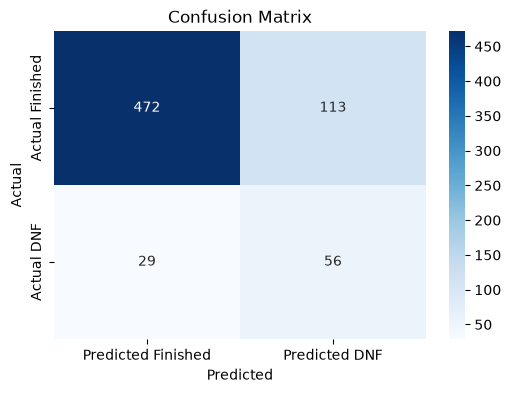

In [5]:
# Confusion Matrix for Logistic Regression Model
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Finished', 'Predicted DNF'],
            yticklabels=['Actual Finished', 'Actual DNF'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')

In [6]:
# Decision Tree Classifier Model
dstree_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dstree_model.fit(X_train, y_train)

ds_prediction = dstree_model.predict(X_test)

f1 = f1_score(y_test, ds_prediction)
print(f"Standalone F1-Score: {f1:.4f}\n")


print("--- Classification Report ---")
print(classification_report(y_test, ds_prediction, target_names=['Finished', 'DNF']))
dstree_report = classification_report(y_test, ds_prediction, target_names=['Finished', 'DNF'], output_dict=True)

Standalone F1-Score: 0.6710

--- Classification Report ---
              precision    recall  f1-score   support

    Finished       0.94      0.97      0.96       585
         DNF       0.74      0.61      0.67        85

    accuracy                           0.92       670
   macro avg       0.84      0.79      0.81       670
weighted avg       0.92      0.92      0.92       670



Text(0.5, 1.0, 'Confusion Matrix')

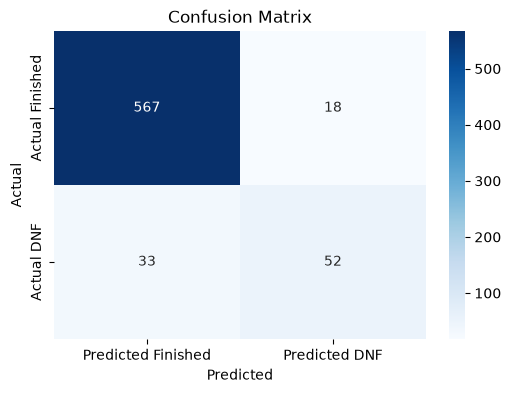

In [7]:
# Confusion Matrix for Decision Tree Classifier Model
cm = confusion_matrix(y_test, ds_prediction)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Finished', 'Predicted DNF'],
            yticklabels=['Actual Finished', 'Actual DNF'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')

In [8]:
# Random Forest Classifier Model
rforest_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rforest_model.fit(X_train, y_train)

rf_prediction = rforest_model.predict(X_test)

f1 = f1_score(y_test, rf_prediction)
print(f"Standalone F1-Score: {f1:.4f}\n")


print("--- Classification Report ---")
print(classification_report(y_test, rf_prediction, target_names=['Finished', 'DNF']))
rforest_report =  classification_report(y_test, rf_prediction, target_names=['Finished', 'DNF'], output_dict=True)

Standalone F1-Score: 0.5736

--- Classification Report ---
              precision    recall  f1-score   support

    Finished       0.92      0.99      0.95       585
         DNF       0.84      0.44      0.57        85

    accuracy                           0.92       670
   macro avg       0.88      0.71      0.76       670
weighted avg       0.91      0.92      0.91       670



Text(0.5, 1.0, 'Confusion Matrix')

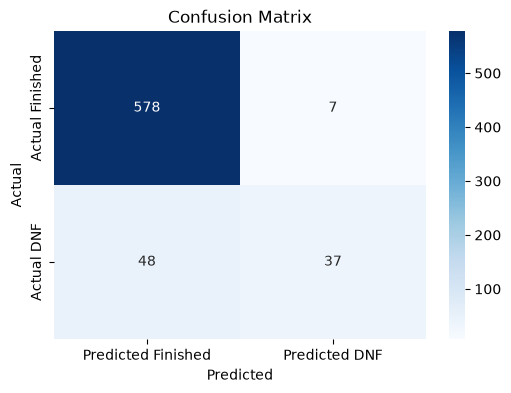

In [9]:
# Confusion Matrix for Random Forest Classifier Model
cm = confusion_matrix(y_test, rf_prediction)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Finished', 'Predicted DNF'],
            yticklabels=['Actual Finished', 'Actual DNF'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')

In [10]:
# XGBoost Classifier Model
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xg_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

xg_model.fit(X_train, y_train)

xg_prediction = xg_model.predict(X_test)

f1 = f1_score(y_test, xg_prediction)
print(f"Standalone F1-Score: {f1:.4f}\n")


print("--- Classification Report ---")
print(classification_report(y_test, xg_prediction, target_names=['Finished', 'DNF']))
xg_report = classification_report(y_test, xg_prediction, target_names=['Finished', 'DNF'], output_dict=True)

Standalone F1-Score: 0.6939

--- Classification Report ---
              precision    recall  f1-score   support

    Finished       0.94      0.98      0.96       585
         DNF       0.82      0.60      0.69        85

    accuracy                           0.93       670
   macro avg       0.88      0.79      0.83       670
weighted avg       0.93      0.93      0.93       670



Text(0.5, 1.0, 'Confusion Matrix')

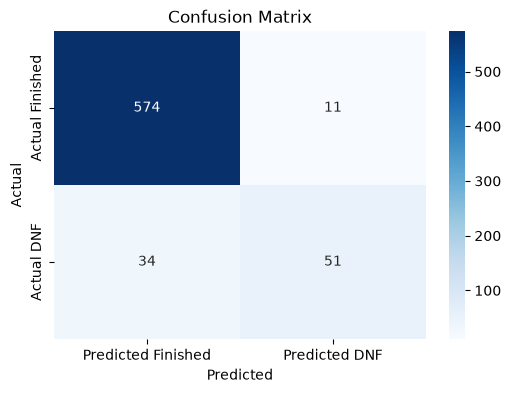

In [11]:
# Confusion Matrix for XGBoost Classifier Model
cm = confusion_matrix(y_test, xg_prediction)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Finished', 'Predicted DNF'],
            yticklabels=['Actual Finished', 'Actual DNF'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')

In [12]:
models_classification_report = {
    'Logistic Regression': prediction,
    'Decision Tree': ds_prediction,
    'Random Forest': rf_prediction,
    'XGBoost': xg_prediction
}

results = []

for model_name, y_pred in models_classification_report.items():
    # Get the dictionary report
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    
    # Extract the weighted average (useful if classes are imbalanced)
    metrics = report_dict['weighted avg']
    
    # Store the row data
    results.append({
        'Model': model_name,
        'F1 Score': round(metrics['f1-score'], 4),
        'Precision': round(metrics['precision'], 4),
        'Recall': round(metrics['recall'], 4)
    })

In [13]:
# Saving results to a Parquet file for further analysis or reporting
results_df = pd.DataFrame(results)
results_df.to_parquet('../data/model_results.parquet', index=False)
results_df

,Model,F1 Score,Precision,Recall
0,Logistic Regression,0.8149,0.8646,0.7881
1,Decision Tree,0.9207,0.9194,0.9239
2,Random Forest,0.9063,0.9129,0.9179
3,XGBoost,0.9282,0.9287,0.9328


In [14]:
# Extracting the best model based on F1 Score
models = {"Logistic Regression": lr_model, "Decision Tree": dstree_model, "Random Forest": rforest_model, "XGBoost": xg_model}
best_model_name = results_df.loc[results_df['F1 Score'].idxmax()]['Model']
best_model = models[best_model_name]
# Most of the time, XGBoost is the best model, but this can vary based on the dataset and hyperparameters.

In [15]:
def plot_feature_importance(best_model, feature_names, top_n=20):
    # 1. Extract feature importances
    importances = best_model.feature_importances_

    # 2. Combine, sort, and KEEP ONLY TOP N
    # Sorting ascending puts the highest at the bottom of the Series. 
    # Using .tail(top_n) grabs only those highest values.
    importance_df = (pd.Series(importances, index=feature_names)
                     .sort_values(ascending=True)
                     .tail(top_n))

    plt.figure(figsize=(10, 6))
    

    importance_df.plot(kind='barh', color='steelblue', edgecolor='black')

    plt.title(f'Feature Importance — Best Model (Top {top_n})', fontsize=14, fontweight='bold')
    plt.xlabel('Relative Importance')
    plt.ylabel('Features')
    
    plt.tight_layout()

    # 3. Save the figure
    save_path = '../images/feature_importance.png'
    plt.savefig(save_path, dpi=300)
    print(f"Plot successfully saved to {save_path}")
    

Plot successfully saved to ../images/feature_importance.png


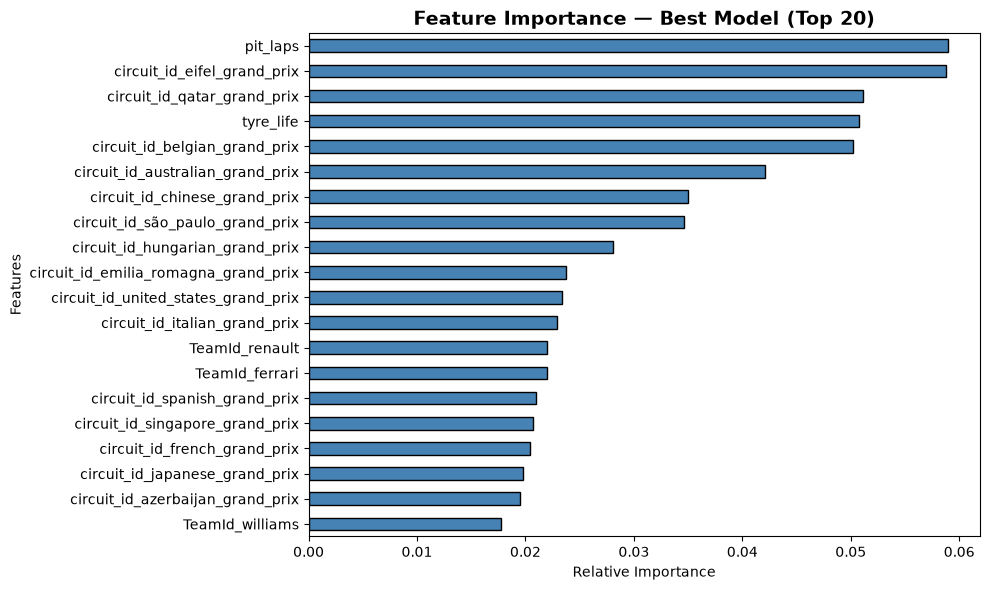

In [16]:
plot_feature_importance(best_model, X.columns)

In [17]:
# Saving the best model to a file for future use
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_model.pkl')

['../models/best_model.pkl']